**Направления анализа**
1. Проверить качество данных: пропуски, дубликаты userid, корректность значений и распределение пользователей между gate_30 и gate_40.
2. Изучить игровую активность: сравнить распределение sum_gamerounds по группам, найти экстремальные значения и оценить, как они влияют на среднее. Показать распределение на графиках.
3. Сравнить retention: рассчитать долю вернувшихся на 1-й и 7-й день в каждой группе, абсолютную и относительную разницу.
4. Узнать как перенос ворот с уровня 30 на уровень 40 связан с возвращаемостью игроков.



Загружаем библиотеки

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
from scipy.stats import binomtest
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import mannwhitneyu

In [ ]:
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

In [ ]:
df = pd.read_csv("cookie_cats.csv")
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


EDA

In [ ]:
print("Размер таблицы:", df.shape)
display(df.head())
display(df.sample(5, random_state=42))
df.info()

Размер таблицы: (90189, 5)


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


,userid,version,sum_gamerounds,retention_1,retention_7
29359,3266525,gate_30,9,False,False
35556,3937667,gate_30,185,True,True
25701,2861986,gate_30,213,True,True
54658,6067319,gate_30,1,False,False
67727,7505400,gate_30,15,True,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


In [ ]:
 #проверка пропущенных значений, дубликатов, уникальных значений
data_cheking = pd.DataFrame({
    "dtype": df.dtypes,
    "missing": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100,
    "unique": df.nunique()
})
display(data_cheking)
print("Повторяющихся userid:", df["userid"].duplicated().sum())

,dtype,missing,missing_pct,unique
userid,int64,0,0.0000,90189
version,object,0,0.0000,2
sum_gamerounds,int64,0,0.0000,942
retention_1,bool,0,0.0000,2
retention_7,bool,0,0.0000,2


Повторяющихся userid: 0


In [ ]:
#распределения
for column in ["version", "retention_1", "retention_7"]:
    print(f"\nРаспределение {column}:")
    display(
        df[column]
        .value_counts(dropna=False)
        .rename_axis(column)
        .to_frame("users")
        .assign(share=lambda x: x["users"] / len(df))
    )



Распределение version:


,users,share
version,,
gate_40,45489,0.5044
gate_30,44700,0.4956



Распределение retention_1:


,users,share
retention_1,,
False,50036,0.5548
True,40153,0.4452



Распределение retention_7:


,users,share
retention_7,,
False,73408,0.8139
True,16781,0.1861


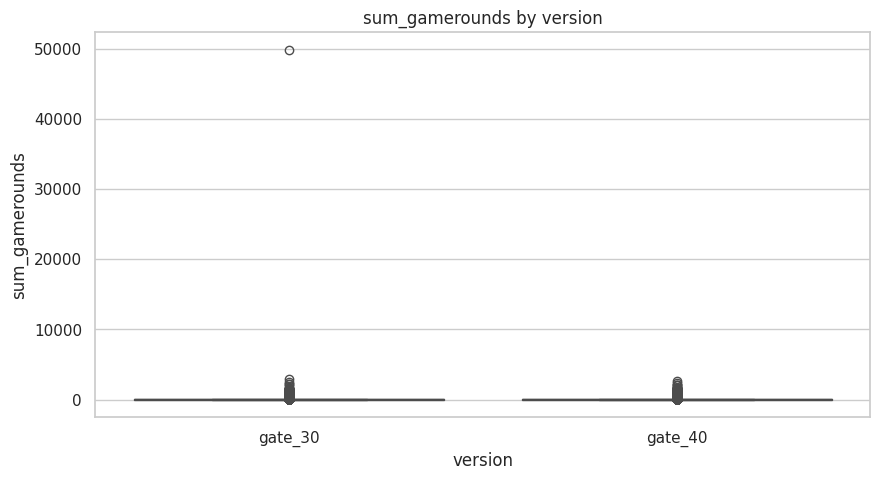

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(x='version', y='sum_gamerounds', data=df)
plt.title('sum_gamerounds by version')
plt.show()

In [ ]:
df[df['sum_gamerounds'] > 40000]

,userid,version,sum_gamerounds,retention_1,retention_7
57702,6390605,gate_30,49854,False,True


В группе gate_30 выделяется одно экстремальное наблюдение — около 50 тыс. раундов, тогда как остальные значения существенно ниже. Но нельзя однозначно утверждать, что это ошибка в данных

In [ ]:
#10 ближайших значений к экстремальному
df.nlargest(10, "sum_gamerounds")[
    ["userid", "version", "sum_gamerounds", "retention_1", "retention_7"]
]

,userid,version,sum_gamerounds,retention_1,retention_7
57702,6390605,gate_30,49854,False,True
7912,871500,gate_30,2961,True,True
29417,3271615,gate_40,2640,True,False
43671,4832608,gate_30,2438,True,True
48188,5346171,gate_40,2294,True,True
46344,5133952,gate_30,2251,True,True
87007,9640085,gate_30,2156,True,True
36933,4090246,gate_40,2124,True,True
88328,9791599,gate_40,2063,True,True
6536,725080,gate_40,2015,True,True


In [ ]:
rounds_without_extreme = df[df["userid"] != 6390605]

print("Все пользователи:")
display(
    df.groupby("version")["sum_gamerounds"]
      .agg(["count", "mean", "median"])
)

print("Без пользователя 6390605:")
display(
    rounds_without_extreme.groupby("version")["sum_gamerounds"]
                          .agg(["count", "mean", "median"])
)

Все пользователи:


,count,mean,median
version,,,
gate_30,44700,52.4563,17.0000
gate_40,45489,51.2988,16.0000


Без пользователя 6390605:


,count,mean,median
version,,,
gate_30,44699,51.3421,17.0000
gate_40,45489,51.2988,16.0000


Исключение экстремального значения почти не меняет среднее число раундов внутри gate_30 и не меняет медиану. При этом разница относительно среднего практически исчезает. Поэтому среднее чувствительно к этой записи

In [ ]:
df['sum_gamerounds'].describe()

,sum_gamerounds
count,90189.0000
mean,51.8725
std,195.0509
min,0.0000
25%,5.0000
50%,16.0000
75%,51.0000
max,49854.0000


Text(0.5, 1.0, 'Распределение sum_gamerounds без выброса')

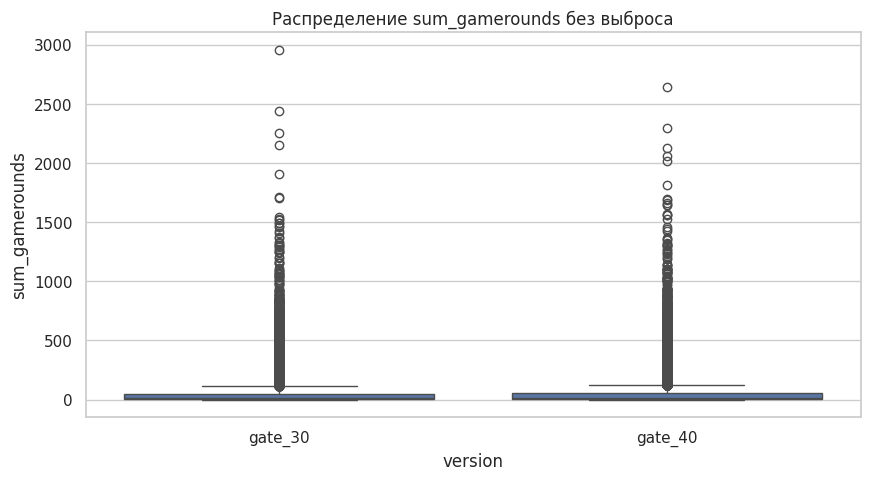

In [ ]:
df_clean = df[df['sum_gamerounds'] <= 40000].copy()
plt.figure(figsize=(10, 5))
sns.boxplot(
    x='version',
    y='sum_gamerounds',
    data=df_clean
)
plt.title('Распределение sum_gamerounds без выброса')

Итог: по данным нельзя определить, связано ли оно с поведением игрока или ошибкой сбора данных. Наблюдение существенно влияет на разницу средних между группами: после его исключения средние становятся почти равными, а медиана gate_30 не меняется. Поэтому для сравнения игровой активности буду смотреть на результаты как на полной выборке, так и без этого пользователя. Из расчёта retention запись не исключаю: оснований считать значения retention ошибочными нет.

In [ ]:
display(df_clean['sum_gamerounds'].describe())

,sum_gamerounds
count,90188.0000
mean,51.3203
std,102.6827
min,0.0000
25%,5.0000
50%,16.0000
75%,51.0000
max,2961.0000


Распределение сильно скошено вправо: медана луше и точнее описывает поведение игроков, чем среднее

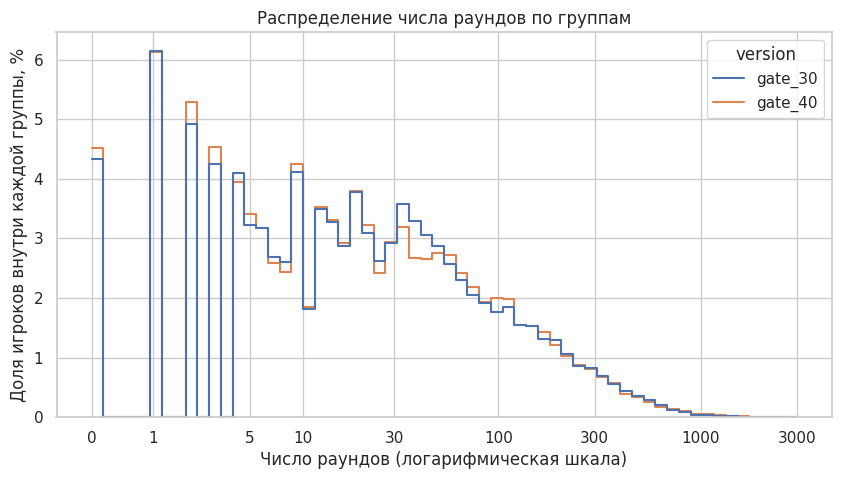

In [ ]:
rounds_plot = rounds_without_extreme.copy()
rounds_plot["rounds_log"] = np.log1p(rounds_plot["sum_gamerounds"])
plt.figure(figsize=(10, 5))
sns.histplot(
    data=rounds_plot,
    x="rounds_log",
    hue="version",
    bins=60,
    stat="percent",
    common_norm=False,
    element="step",
    fill=False
)

ticks = [0, 1, 5, 10, 30, 100, 300, 1000, 3000]
plt.xticks(np.log1p(ticks), ticks)
plt.title("Распределение числа раундов по группам")
plt.xlabel("Число раундов (логарифмическая шкала)")
plt.ylabel("Доля игроков внутри каждой группы, %")
plt.show()

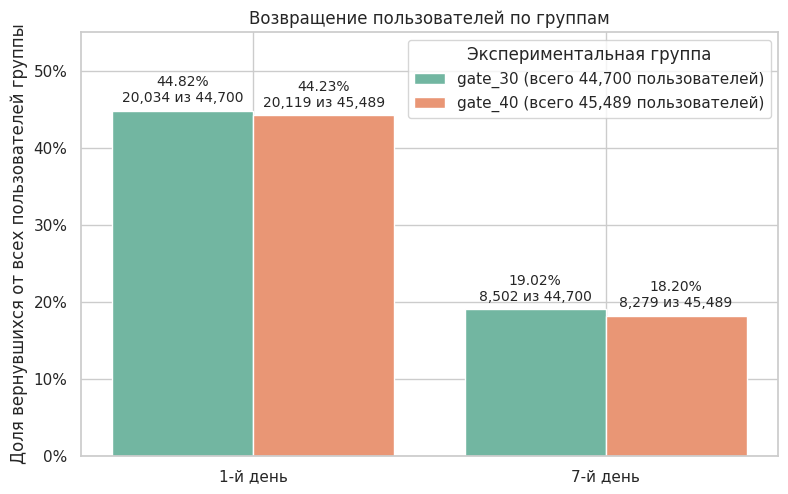

In [ ]:
metrics = ["retention_1", "retention_7"]
groups = ["gate_30", "gate_40"]
summary = df.groupby("version").agg(
    users=("userid", "count"),
    retained_1=("retention_1", "sum"),
    retained_7=("retention_7", "sum"),
)

x = np.arange(len(metrics))
fig, ax = plt.subplots(figsize=(9, 5.5))
for i, group in enumerate(groups):
    users = summary.loc[group, "users"]
    counts = [
        summary.loc[group, "retained_1"],
        summary.loc[group, "retained_7"],
    ]
    rates = [count / users for count in counts]
    bars = ax.bar(
        x + (i - 0.5) * 0.4,
        rates,
        0.4,
        label=f"{group} (всего {users:,} пользователей)",
        color="#72B6A1" if group == 'gate_30' else "#E99675",
    )

    for bar, count, rate in zip(bars, counts, rates):
        ax.annotate(
            f"{rate:.2%}\n{count:,} из {users:,}",
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=10,
        )
ax.set_xticks(x, ["1-й день", "7-й день"])
ax.set_ylabel("Доля вернувшихся от всех пользователей группы")
ax.set_title("Возвращение пользователей по группам")
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_ylim(0, 0.55)
ax.legend(title="Экспериментальная группа")
plt.show()

В обеих группах доля пользователей, вернувшихся на 1-й день, выше доли вернувшихся на 7-й день. В группе gate_40 наблюдаемый retention ниже, чем в gate_30: 44,23% против 44,82% на 1-й день и 18,20% против 19,02% на 7-й.

Для корреляционного анализа выбран коэффициент Спирмена. Распределение sum_gamerounds сильно скошено вправо и содержит экстремальное значение. Спирмен рассчитывает связь по рангам, поэтому величина такого значения меньше влияет на коэффициент, чем при корреляции Пирсона.

,gate_40,sum_gamerounds,retention_1,retention_7
gate_40,1.0000,-0.0070,-0.0060,-0.0110
sum_gamerounds,-0.0070,1.0000,0.6280,0.5240
retention_1,-0.0060,0.6280,1.0000,0.3270
retention_7,-0.0110,0.5240,0.3270,1.0000


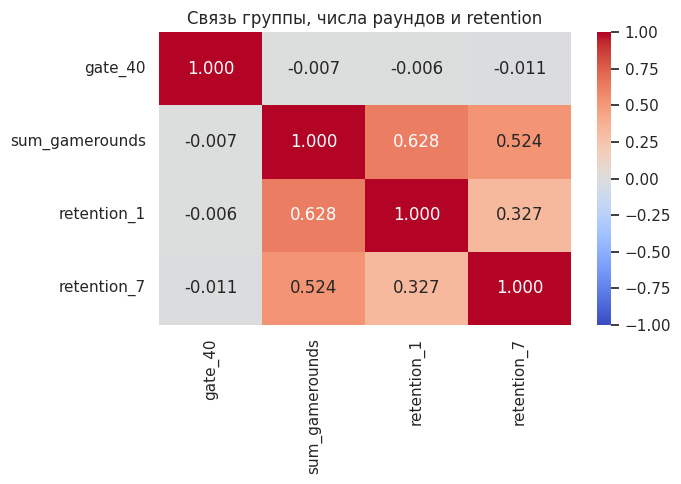

In [ ]:
corr_data = df[["version", "sum_gamerounds", "retention_1", "retention_7"]].copy()

corr_data["gate_40"] = (corr_data["version"] == "gate_40").astype(int)
corr_data["retention_1"] = corr_data["retention_1"].astype(int)
corr_data["retention_7"] = corr_data["retention_7"].astype(int)

corr_matrix = corr_data[
    ["gate_40", "sum_gamerounds", "retention_1", "retention_7"]
].corr(method="spearman")

display(corr_matrix.round(3))

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)
plt.title("Связь группы, числа раундов и retention")
plt.tight_layout()
plt.show()

Корреляционный анализ показал положительную связь числа сыгранных раундов с возвращением игроков на 1-й и 7-й день. Связь варианта ворот с retention по величине очень слабая и отрицательная.

А/В тест

Перед анализом результатов проверим соответствие фактического распределения пользователей предполагаемому распределению 50/50. Такая проверка называется Sample Ratio Mismatch, или SRM. Она помогает обнаружить возможные проблемы с распределением пользователей между вариантами, например ошибку рандомизации, потерю наблюдений или некорректную запись группы.

Гипотезы:

\(H_0\): пользователи распределены между gate_30 и gate_40 в соотношении 50/50.

\(H_1\): фактическое распределение отличается от 50/50.

In [ ]:
group_sizes = df["version"].value_counts().reindex(["gate_30", "gate_40"])
display(group_sizes)
srm = binomtest(
    k=group_sizes["gate_40"],
    n=group_sizes.sum(),
    p=0.5
)

print(f"p-value проверки распределения 50/50: {srm.pvalue:.4f}")

,count
version,
gate_30,44700
gate_40,45489


p-value проверки распределения 50/50: 0.0087


В группу gate_30 попало 44 700 пользователей, в gate_40 - 45 489. При проверке ожидаемого распределения 50/50 получено p-value = 0.0087. При уровне значимости 5% нулевая гипотеза отклоняется: наблюдаемое соотношение групп статистически отличается от 50/50. Однако в датасете нет информации о запланированном соотношении групп, поэтому нельзя утверждать, что распределение выполнено некорректно.

Цель эксперимента - определить, влияет ли перенос ворот с 30-го уровня на 40-й на возвращаемость игроков.

Контрольная группа: gate_30.
Тестовая группа: gate_40.
Уровень значимости: alpa = 0.05
Тест: двусторонний, поскольку заранее не было зафиксировано направление эффекта
| Тип | Метрика | Назначение | Метод |
|---|---|---|---|
| Целевая | `retention_7` | Долгосрочное возвращение | z-тест двух долей |
| Защитная | `retention_1` | Раннее возвращение | z-тест двух долей |
| Proxy | `sum_gamerounds` | Игровая активность | критерий Манна — Уитни |

Обоснование выбранных методов: для метрик возвращаемости я выбрала z-тест для долей, поскольку метрика бинарная, группы независимы, а наблюдений достаточно. Выбран двусторонний критерий, поскольку до проведения анализа направление возможного эффекта не было задано. Я хочу проверить наличие любого различия между группами: как увеличение, так и снижение метрики в gate_40 относительно gate_30.

retention_7 выбираем целевой метрикой, поскольку эффект расположения ворот может проявиться не сразу: игроку требуется время, чтобы приблизиться к соответствующему уровню.

Гипотезы для целевой метрики

Обозначим:

\(p_{30}\) — retention 7-го дня в контрольной группе;
\(p_{40}\) — retention 7-го дня в тестовой группе.

Тогда:
Перенос ворот не связан с изменением retention 7-го дня.
$$ H_0: p_{40}=p_{30} $$


Retention 7-го дня различается между вариантами.
$$ H_1: p_{40}\ne p_{30} $$

In [ ]:
def retention_ztest(data, metric, alpha=0.05):
    control = data[data["version"] == "gate_30"][metric]
    test = data[data["version"] == "gate_40"][metric]
    n_control = len(control)
    n_test = len(test)
    success_control = control.sum()
    success_test = test.sum()
    rate_control = control.mean()
    rate_test = test.mean()
    count = np.array([success_test, success_control])
    nobs = np.array([n_test, n_control])
    z_stat, p_value = proportions_ztest(
        count=count,
        nobs=nobs,
        alternative="two-sided"
    )
    difference = rate_test - rate_control
    standard_error = np.sqrt(
        rate_test * (1 - rate_test) / n_test
        + rate_control * (1 - rate_control) / n_control
    )
    ci_lower = difference - 1.96 * standard_error
    ci_upper = difference + 1.96 * standard_error
    return pd.Series({
        "metric": metric,
        "control_users": n_control,
        "test_users": n_test,
        "control_retention": rate_control,
        "test_retention": rate_test,
        "difference_pp": difference * 100,
        "ci_lower_pp": ci_lower * 100,
        "ci_upper_pp": ci_upper * 100,
        "z_stat": z_stat,
        "p_value": p_value,
        "significant": p_value < alpha
    })
retention_7_result = retention_ztest(df, "retention_7")
display(retention_7_result)

,0
metric,retention_7
control_users,44700
test_users,45489
control_retention,0.1902
test_retention,0.1820
difference_pp,-0.8201
ci_lower_pp,-1.3282
ci_upper_pp,-0.3121
z_stat,-3.1644
p_value,0.0016


In [ ]:
print(f"Retention gate_30: {retention_7_result['control_retention']:.2%}")
print(f"Retention gate_40: {retention_7_result['test_retention']:.2%}")

print(
    f"Разница gate_40 − gate_30: "
    f"{retention_7_result['difference_pp']:.2f} п.п."
)

print(
    f"95% ДИ: "
    f"[{retention_7_result['ci_lower_pp']:.2f}; "
    f"{retention_7_result['ci_upper_pp']:.2f}] п.п."
)
print(f"z-статистика: {retention_7_result['z_stat']:.4f}")
print(f"p-value: {retention_7_result['p_value']:.4f}")

Retention gate_30: 19.02%
Retention gate_40: 18.20%
Разница gate_40 − gate_30: -0.82 п.п.
95% ДИ: [-1.33; -0.31] п.п.
z-статистика: -3.1644
p-value: 0.0016


In [ ]:
retention_1_result = retention_ztest(df, "retention_1")

display(retention_1_result)
retention_results = pd.DataFrame([
    retention_7_result,
    retention_1_result
])

display(
    retention_results[
        [
            "metric",
            "control_retention",
            "test_retention",
            "difference_pp",
            "ci_lower_pp",
            "ci_upper_pp",
            "p_value",
            "significant"
        ]
    ].style.format({
        "control_retention": "{:.2%}",
        "test_retention": "{:.2%}",
        "difference_pp": "{:.2f}",
        "ci_lower_pp": "{:.2f}",
        "ci_upper_pp": "{:.2f}",
        "p_value": "{:.4f}"
    })
)

,0
metric,retention_1
control_users,44700
test_users,45489
control_retention,0.4482
test_retention,0.4423
difference_pp,-0.5905
ci_lower_pp,-1.2393
ci_upper_pp,0.0582
z_stat,-1.7841
p_value,0.0744


,metric,control_retention,test_retention,difference_pp,ci_lower_pp,ci_upper_pp,p_value,significant
0,retention_7,19.02%,18.20%,-0.82,-1.33,-0.31,0.0016,True
1,retention_1,44.82%,44.23%,-0.59,-1.24,0.06,0.0744,False


Retention 1-го дня в тестовой группе оказался на 0,59 п.п. ниже контрольной: 44,23% против 44,82%. Однако различие статистически незначимо (p = 0,0744), а 95%-й доверительный интервал [−1,24; 0,06] п.п. включает ноль. Следовательно, достаточных оснований утверждать, что перенос ворот изменил retention 1-го дня, нет.

Retention 7-го дня составил 19,02% в контрольной группе и 18,20% в тестовой. Разница равна − 0,82 п.п. и статистически значима (z = −3,16, p = 0,0016). Нулевая гипотеза об отсутствии эффекта отвергается. 95%-й доверительный интервал для эффекта составляет от −1,33 до −0,31 п.п. Таким образом, данные указывают на снижение retention 7-го дня после переноса ворот на 40-й уровень.  

Помимо retention, сравним sum_gamerounds. Эта метрика отражает игровую активность пользователя за период наблюдения и помогает дополнить интерпретацию эксперимента. Перенос ворот может изменить игровой прогресс и мотивацию продолжать игру, что потенциально проявится как в возвращаемости, так и в количестве сыгранных раундов. Поэтому sum_gamerounds используется как дополнительная метрика.
Для сравнения sum_gamerounds применяется критерий Манна - Уитни. Распределение числа раундов сильно скошено вправо и содержит экстремальное наблюдение, поэтому для данной числовой метрики нецелесообразно использовать параметрические тесты, которые трубуют нормальности распределения. Манна - Уитни использует ранги и наименее чувствителен к выбросам. Он проверяет различие распределений между группами, а не непосредственно равенство средних.

Гипотеза:

H_0: перенос ворот с 40 уровня на 30 не влияет на активность

H_1: перенос ворот влияет на игровую активность

In [ ]:
def mann_whitney_test(data):
    control = data.loc[
        data["version"] == "gate_30",
        "sum_gamerounds"
    ]
    test = data.loc[
        data["version"] == "gate_40",
        "sum_gamerounds"
    ]
    u_stat, p_value = mannwhitneyu(
        test,
        control,
        alternative="two-sided",
        method="asymptotic"
    )
    return pd.Series({
        "n_gate_30": len(control),
        "n_gate_40": len(test),
        "median_gate_30": control.median(),
        "median_gate_40": test.median(),
        "mean_gate_30": control.mean(),
        "mean_gate_40": test.mean(),
        "u_stat": u_stat,
        "p_value": p_value
    })
rounds_all_result = mann_whitney_test(df)
df_without_extreme = df[df["userid"] != 6390605].copy()
rounds_clean_result = mann_whitney_test(df_without_extreme)
rounds_results = pd.DataFrame({
    "Все наблюдения": rounds_all_result,
    "Без экстремального значения": rounds_clean_result
})

display(rounds_results)

,n_gate_30,n_gate_40,median_gate_30,median_gate_40,mean_gate_30,mean_gate_40,u_stat,p_value
Все наблюдения,44700.0000,45489.0000,17.0000,16.0000,52.4563,51.2988,1009027049.5000,0.0502
Без экстремального значения,44699.0000,45489.0000,17.0000,16.0000,51.3421,51.2988,1009027049.5000,0.0509


Медианное число раундов составляет 17 в группе gate_30 и 16 в группе gate_40. Критерий Манна - Уитни не выявил статистически значимого различия распределений при уровне значимости 5%: на полной выборке 0.0502, без экстремального наблюдения 0.0509. Исключение аномального значения не изменило статистический вывод, поэтому результат теста устойчив

**Выводы**

1. Перенос ворот с 30 на 40 уровень не показал положительного влияния на метрики (активность, возвращаемость 1-го дня, возвращаемость 7-го дня). Retention_1 в тестовой группе показал спад 0.59 процентных пунктов, но разница не стат.значима. Retention 7-го дня составил 19,02% в контрольной группе и 18,20% в тестовой, однако разница оказалась стат.значима (p=0.0016).
2. Критерий Манна - Уитни не выявил статистически значимого различия в распределении числа сыгранных раундов. Вывод сохранился после исключения экстремального наблюдения. Таким образом, перенос ворот не дал подтверждённого роста игровой активности и одновременно ухудшил основную метрику retention_7.
3. На основании имеющихся данных перенос ворот на 40-й уровень внедрять не рекомендуется. Более безопасное решение - сохранить ворота на 30-м уровне и дополнительно исследовать причины снижения долгосрочного retention.

Наблюдения:
1. В датасете отсутствуют даты установки и игровых сессий, описание формирования когорт и методика расчёта retention. Поэтому невозможно самостоятельно пересчитать retention, проверить полноту окна наблюдения и исключить наличие пользователей, для которых семидневный период ещё не завершился. Анализ основан на предположении, что бинарные признаки retention_1 и retention_7 рассчитаны корректно и одинаково для обеих групп. Кроме того, в данных нет информации о достигнутых уровнях и времени прохождения игры, поэтому невозможно определить, дошёл ли пользователь до ворот на 30-м или 40-м уровне и столкнулся ли он фактически с экспериментальным изменением.

Продуктовые гипотезы относительно полученных результатов:
1. На снижение retention 40 уровня относительно 30 уровня может указывать резкое повышение сложности игры, что снижает мотивацию, надоедает и, как итог, вызывает отток пользователей.
2. Новые, опытные, платящие и очень активные пользователи могут реагировать по-разному на обновления в игре. В текущем датасете нет признаков для такой сегментации.
3. Ворота на 30-м уровне раньше прерывают длинную игровую сессию. Пользователь отдыхает и возвращается позже. При воротах на 40-м уровне он может играть дольше, быстрее устать и потерять интерес.
4. Быстрое увлечение игрой и быстрая усталось от нее: более позднее ограничение позволяет пройти больше уровней за первые сессии. Это может увеличить краткосрочное потребление игры, но снизить мотивацию возвращаться через неделю.

**Выводы**
1. Перенос ворот с 30-го на 40-й уровень не показал положительного влияния на исследуемые метрики. Retention_1 в тестовой группе снизился на 0,59 п.п., однако различие статистически незначимо (p = 0,0744, 95% ДИ [−1,24; 0,06] п.п.). Поэтому достаточных оснований утверждать, что перенос ворот изменил retention 1-го дня, нет.
2. Retention_7 составил 19,02% в контрольной группе и 18,20% в тестовой. Снижение на 0,82 п.п. статистически значимо (p = 0,0016, 95% ДИ [−1,33; −0,31] п.п.). Таким образом, перенос ворот на 40-й уровень связан со снижением retention 7-го дня.
3. Критерий Манна - Уитни не выявил статистически значимого различия в распределении числа сыгранных раундов. Результат сохранился после исключения экстремального наблюдения. Следовательно, подтверждённого роста игровой активности в тестовой группе не обнаружено.
4. На основании имеющихся данных перенос ворот на 40-й уровень внедрять не рекомендуется: изменение не улучшило ранний retention и игровую активность, при этом статистически значимо ухудшило retention 7-го дня. Более безопасное решение - сохранить ворота на 30-м уровне и дополнительно исследовать механизм снижения долгосрочной возвращаемости.

**Ограничения анализа**

1. В датасете отсутствуют даты установки и игровых сессий, описание формирования когорт и методика расчёта retention. Поэтому невозможно самостоятельно пересчитать retention, проверить полноту окна наблюдения и исключить наличие пользователей, для которых семидневный период ещё не завершился. Анализ основан на предположении, что признаки retention_1 и retention_7 рассчитаны корректно и одинаково для обеих групп.
2. В данных нет информации о достигнутых уровнях и времени прохождения игры. Поэтому невозможно определить, дошёл ли пользователь до ворот на 30-м или 40-м уровне и столкнулся ли он фактически с экспериментальным изменением. Результат отражает эффект назначения варианта на всю группу, включая пользователей, которые могли не дойти до ворот.
3. В датасете отсутствуют характеристики пользователей до эксперимента. Поэтому нельзя проверить исходную однородность групп и устойчивость эффекта по содержательным сегментам: платформе, стране, источнику трафика, опыту или платежеспособности.
4. При предположении распределения трафика 50/50 размеры групп статистически отличаются от ожидаемых (p = 0,0087). Однако плановая пропорция неизвестна, поэтому нельзя определить, связано ли это с проблемой рандомизации. Перед продуктовым решением следует проверить настройки эксперимента.

**Продуктовые гипотезы**

1. Участок между 30-м и 40-м уровнями может содержать рост сложности. Если игрок сталкивается с серией неудач без промежуточной паузы, его мотивация продолжать игру может снижаться. Для проверки нужна воронка прохождения уровней и число попыток на каждом уровне.
2. Ворота на 30-м уровне могут создавать естественную паузу в игровой сессии. После неё пользователь отдыхает и возвращается позже. При переносе ворот на 40-й уровень игрок может дольше играть без перерыва, быстрее устать и потерять интерес.
3. Более позднее ограничение может позволить быстрее потребить доступный контент в первых сессиях. Это способно поддерживать краткосрочную активность, но снижать мотивацию вернуться через неделю.
4. Эффект может различаться между новыми, опытными, платящими и наиболее активными игроками. Для проверки этой гипотезы нужны пользовательские характеристики, измеренные до эксперимента.